# Restaurant Sales Insight

### Executive analysis notebook · portfolio edition

Notebook ini menerjemahkan output pipeline produksi menjadi cerita bisnis yang ringkas, dapat diaudit, dan dapat dijalankan ulang. Fokus analisis adalah **recorded revenue**, bauran produk, lokasi, kanal, metode pembayaran, serta hipotesis peluang yang perlu divalidasi lebih lanjut.

> **Catatan penting:** satu baris sumber adalah catatan penjualan produk teragregasi, bukan transaksi pelanggan yang terbukti. Karena itu, jumlah order, AOV, dan metrik pelanggan tidak dihitung.

## Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebook":
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "src").exists():
    raise FileNotFoundError("Jalankan notebook dari root repositori atau folder notebook/.")
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"navy": "#16324F", "blue": "#2F80ED", "teal": "#18A999", "amber": "#F2A541", "red": "#D1495B", "gray": "#667085"}

def money(value):
    return f"{value:,.2f} (currency unspecified)"

def percent(value):
    return f"{value:.1%}"

def compact_table(frame, columns=None, rows=10):
    selected = frame if columns is None else frame[columns]
    return selected.head(rows).style.hide(axis="index")


### Load validated artifacts

Notebook menggunakan artefak CSV/JSON dari `output/`. Jika artefak inti belum ada, pipeline dijalankan otomatis. Semua transformasi utama tetap berada di `src/`, sehingga notebook tidak menggandakan business logic.

In [2]:
required_artifacts = [
    BASE_DIR / "output/kpis/executive_kpis.csv",
    BASE_DIR / "output/analysis/product_performance.csv",
    BASE_DIR / "output/analysis/daily_performance.csv",
    BASE_DIR / "output/insights/opportunity_matrix.csv",
]
if not all(path.exists() for path in required_artifacts):
    from src.pipeline import run_pipeline
    run_pipeline()

paths = {
    "kpis": "output/kpis/executive_kpis.csv",
    "daily": "output/analysis/daily_performance.csv",
    "monthly": "output/analysis/monthly_performance.csv",
    "products": "output/analysis/product_performance.csv",
    "categories": "output/analysis/category_performance.csv",
    "cities": "output/analysis/city_performance.csv",
    "channels": "output/analysis/purchase_type_performance.csv",
    "payments": "output/analysis/payment_method_performance.csv",
    "weekdays": "output/analysis/day_of_week_performance.csv",
    "opportunities": "output/insights/opportunity_matrix.csv",
    "cleaning_audit": "output/cleaning_audit.csv",
}
data = {name: pd.read_csv(BASE_DIR / path) for name, path in paths.items()}
metadata = json.loads((BASE_DIR / "output/project_metadata.json").read_text(encoding="utf-8"))
cleaned = pd.read_csv(BASE_DIR / "output/restaurant_sales_cleaned.csv")
data["daily"]["date"] = pd.to_datetime(data["daily"]["date"])
data["kpis"] = data["kpis"].set_index("metric")

print(f"Loaded {len(paths)} analytical artifacts | cleaned rows: {len(cleaned):,}")


Loaded 11 analytical artifacts | cleaned rows: 254


## tl;dr

In [3]:
kpi_values = pd.to_numeric(data["kpis"]["value"], errors="coerce")
total_revenue = kpi_values["total_revenue"]
sales_records = int(kpi_values["total_sales_records"])
active_days = int(kpi_values["active_sales_days"])
avg_daily_revenue = kpi_values["average_daily_revenue"]
weighted_price = kpi_values["average_selling_price"]
top_product = data["products"].iloc[0]
top_city = data["cities"].iloc[0]
top_channel = data["channels"].iloc[0]

display(Markdown(f''' 
| Headline | Hasil |
|---|---:|
| Recorded revenue | **{money(total_revenue)}** |
| Sales records | **{sales_records:,}** |
| Active sales days | **{active_days:,}** |
| Average daily revenue | **{money(avg_daily_revenue)}** |
| Weighted selling price | **{weighted_price:,.2f}** |

**Cerita utama.** {top_product['product']} menyumbang **{percent(top_product['revenue_share'])}** recorded revenue, sehingga performa sangat terkonsentrasi pada satu produk. {top_city['city']} adalah kota terbesar (**{percent(top_city['revenue_share'])}**), sedangkan {top_channel['purchase_type']} adalah kanal terbesar (**{percent(top_channel['revenue_share'])}**).

**Implikasi.** Lindungi ketersediaan dan kualitas produk utama, lalu uji mix dan price realization pada segmen bervolume tinggi. Jangan menyimpulkan profitabilitas atau perilaku pelanggan tanpa data biaya dan transaksi yang lebih granular.
'''))


 
| Headline | Hasil |
|---|---:|
| Recorded revenue | **769,515.89 (currency unspecified)** |
| Sales records | **254** |
| Active sales days | **53** |
| Average daily revenue | **14,519.17 (currency unspecified)** |
| Weighted selling price | **6.58** |

**Cerita utama.** Burgers menyumbang **49.0%** recorded revenue, sehingga performa sangat terkonsentrasi pada satu produk. Lisbon adalah kota terbesar (**31.4%**), sedangkan Online adalah kanal terbesar (**39.7%**).

**Implikasi.** Lindungi ketersediaan dan kualitas produk utama, lalu uji mix dan price realization pada segmen bervolume tinggi. Jangan menyimpulkan profitabilitas atau perilaku pelanggan tanpa data biaya dan transaksi yang lebih granular.


## Context & Methods

### Business questions

1. Seberapa besar performa penjualan yang terekam?
2. Produk, kategori, kota, kanal, dan metode pembayaran mana yang paling berkontribusi?
3. Apakah pendapatan terkonsentrasi pada sedikit produk atau segmen?
4. Peluang mana yang layak diuji oleh tim bisnis berikutnya?

### Method

Analisis menggunakan agregasi deskriptif dari pipeline tervalidasi: revenue, recorded quantity, jumlah sales records, weighted selling price, revenue share, dan rata-rata per active sales day. Tidak ada klaim kausal.

### Key assumptions and metric boundaries

- **Grain:** satu baris adalah catatan penjualan produk teragregasi dengan `order_id` sumber yang unik; ini tidak membuktikan satu customer order.
- **Currency:** simbol mata uang tidak tersedia, sehingga nilai uang ditampilkan tanpa simbol.
- **Quantity:** unit kuantitas tidak diketahui dan diperlakukan sebagai recorded measure.
- **Time:** periode hanya 7 November–29 Desember 2022 dan kedua bulan bersifat parsial.
- **Revenue ≠ profit:** tidak ada COGS, diskon, margin, kapasitas, atau data inventory.
- **Interpretation:** perbedaan antarsegmen adalah asosiasi deskriptif, bukan dampak kausal.

In [4]:
source_context = pd.DataFrame({
    "Item": ["Dataset", "Analytical grain", "Primary key", "Period", "Rows before", "Rows after", "Removed", "Flagged"],
    "Value": [
        metadata["dataset_source"], metadata["dataset_grain"], metadata["primary_key"],
        f"{metadata['date_range']['start']} to {metadata['date_range']['end']}",
        metadata["row_count_before_cleaning"], metadata["row_count_after_cleaning"],
        metadata["removed_record_count"], metadata["flagged_record_count"],
    ],
})
compact_table(source_context, rows=20)


Item,Value
Dataset,Kaggle dataset rohitgrewal/restaurant-sales-data (per repository documentation)
Analytical grain,one aggregated product sales record with a unique source order_id
Primary key,record_id
Period,2022-11-07 to 2022-12-29
Rows before,254
Rows after,254
Removed,0
Flagged,0


## Data

### Data quality and cleaning audit

Pemeriksaan berikut merekonsiliasi jumlah baris, duplikasi primary key, missing value pada kolom inti, serta tindakan cleaning. Tujuannya adalah memastikan angka headline dapat ditelusuri ke data bersih.

In [5]:
core_columns = [column for column in ["record_id", "date", "product", "quantity", "price", "revenue"] if column in cleaned.columns]
quality_checks = pd.DataFrame({
    "Check": ["Rows reconcile", "Primary key unique", "Core fields complete", "Revenue reconciles to KPI"],
    "Result": [
        len(cleaned) == metadata["row_count_after_cleaning"],
        cleaned[metadata["primary_key"]].is_unique,
        cleaned[core_columns].notna().all().all(),
        np.isclose(cleaned["revenue"].sum(), total_revenue),
    ],
})
audit_summary = (data["cleaning_audit"].groupby(["action", "reason"], as_index=False).size()
                 .sort_values("size", ascending=False))
display(quality_checks.style.hide(axis="index").map(lambda value: "color: #14804A; font-weight: bold" if value is True else ""))
display(Markdown(f"**Audit trail:** {len(data['cleaning_audit']):,} perubahan nilai terdokumentasi; {metadata['removed_record_count']} baris dihapus dan {metadata['flagged_record_count']} baris ditandai."))
compact_table(audit_summary.rename(columns={"size": "records"}), rows=8)


Check,Result
Rows reconcile,True
Primary key unique,True
Core fields complete,True
Revenue reconciles to KPI,True


**Audit trail:** 528 perubahan nilai terdokumentasi; 0 baris dihapus dan 0 baris ditandai.

action,reason,records
repaired,standardized_whitespace,528


## Results

### 1. Revenue trend — stabilitas lebih penting daripada pertumbuhan semu

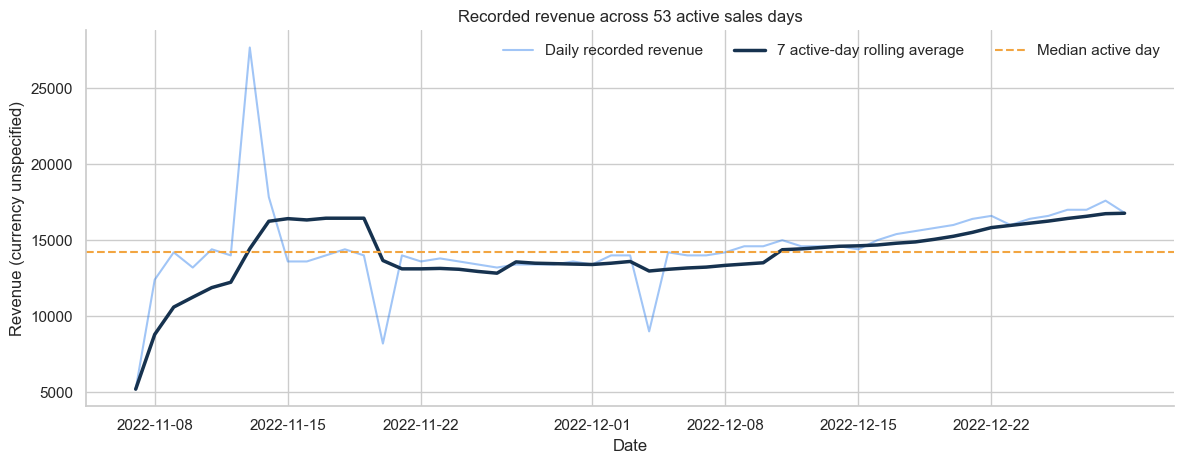

Daily revenue ranges from **5,200.00 (currency unspecified)** to **27,674.46 (currency unspecified)**. The median active day is **14,200.04 (currency unspecified)**. Monthly growth is not treated as a performance claim because November and December are both partial periods.

In [6]:
daily = data["daily"].sort_values("date")
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(daily["date"], daily["revenue"], color=PALETTE["blue"], alpha=.45, linewidth=1.5, label="Daily recorded revenue")
ax.plot(daily["date"], daily["rolling_7_active_day_revenue"], color=PALETTE["navy"], linewidth=2.5, label="7 active-day rolling average")
ax.axhline(daily["revenue"].median(), color=PALETTE["amber"], linestyle="--", label="Median active day")
ax.set(title="Recorded revenue across 53 active sales days", xlabel="Date", ylabel="Revenue (currency unspecified)")
ax.legend(frameon=False, ncol=3)
sns.despine()
plt.tight_layout()
plt.show()

display(Markdown(f"Daily revenue ranges from **{money(daily['revenue'].min())}** to **{money(daily['revenue'].max())}**. The median active day is **{money(daily['revenue'].median())}**. Monthly growth is not treated as a performance claim because November and December are both partial periods."))


### 2. Product portfolio — concentration is the central commercial pattern

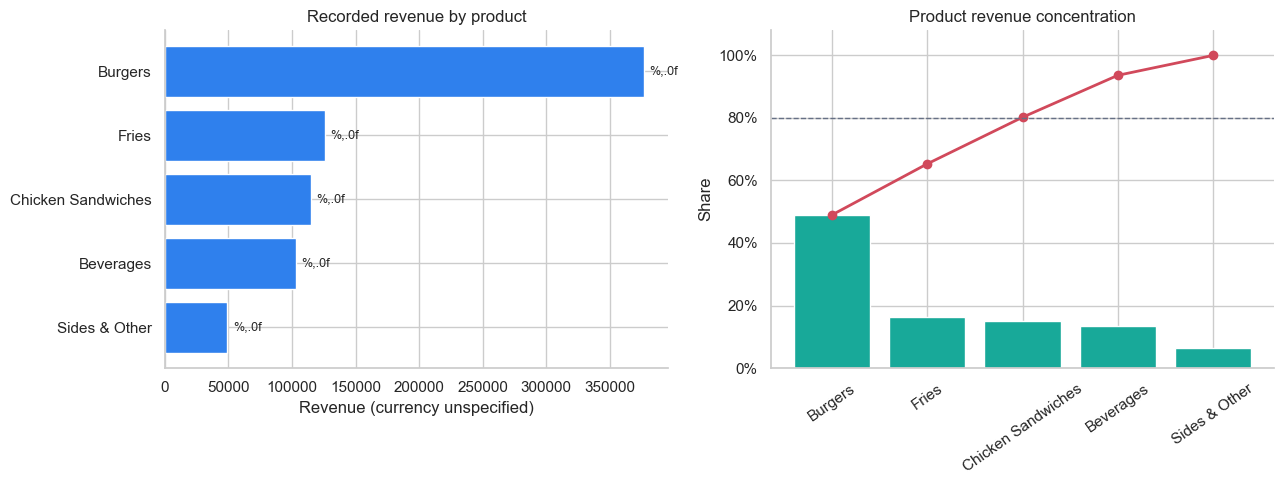

The top three products contribute **80.2%** of recorded revenue. Burgers alone contribute **49.0%**. This is strong evidence of concentration, but not by itself evidence of product profitability or operational risk.

In [7]:
products = data["products"].sort_values("revenue", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(products["product"], products["revenue"], color=PALETTE["blue"])
axes[0].set(title="Recorded revenue by product", xlabel="Revenue (currency unspecified)", ylabel="")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%,.0f", padding=4, fontsize=9)

pareto = data["products"].sort_values("rank_by_revenue")
axes[1].bar(pareto["product"], pareto["revenue_share"], color=PALETTE["teal"])
axes[1].plot(pareto["product"], pareto["cumulative_revenue_share"], color=PALETTE["red"], marker="o", linewidth=2)
axes[1].axhline(.80, color=PALETTE["gray"], linestyle="--", linewidth=1)
axes[1].set(title="Product revenue concentration", xlabel="", ylabel="Share", ylim=(0, 1.08))
axes[1].tick_params(axis="x", rotation=35)
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
sns.despine()
plt.tight_layout()
plt.show()

top_three_share = pareto.head(3)["revenue_share"].sum()
display(Markdown(f"The top three products contribute **{percent(top_three_share)}** of recorded revenue. Burgers alone contribute **{percent(pareto.iloc[0]['revenue_share'])}**. This is strong evidence of concentration, but not by itself evidence of product profitability or operational risk."))


### 3. Category mix — main courses monetize recorded quantity at a higher rate

In [8]:
categories = data["categories"].sort_values("revenue", ascending=False)
category_view = categories[["product_category", "revenue", "quantity", "average_selling_price", "revenue_share"]].copy()
category_view["revenue_share"] = category_view["revenue_share"].map(lambda value: f"{value:.1%}")
compact_table(category_view, rows=10).format({"revenue": "{:,.2f}", "quantity": "{:,.2f}", "average_selling_price": "{:,.2f}"})


product_category,revenue,quantity,average_selling_price,revenue_share
Main Course,"491,641.52","40,158.23",12.24,63.9%
Sides,"174,674.19","41,853.94",4.17,22.7%
Beverage,"103,200.18","34,983.14",2.95,13.4%


### 4. Geography and channel — distinguish scale from price realization

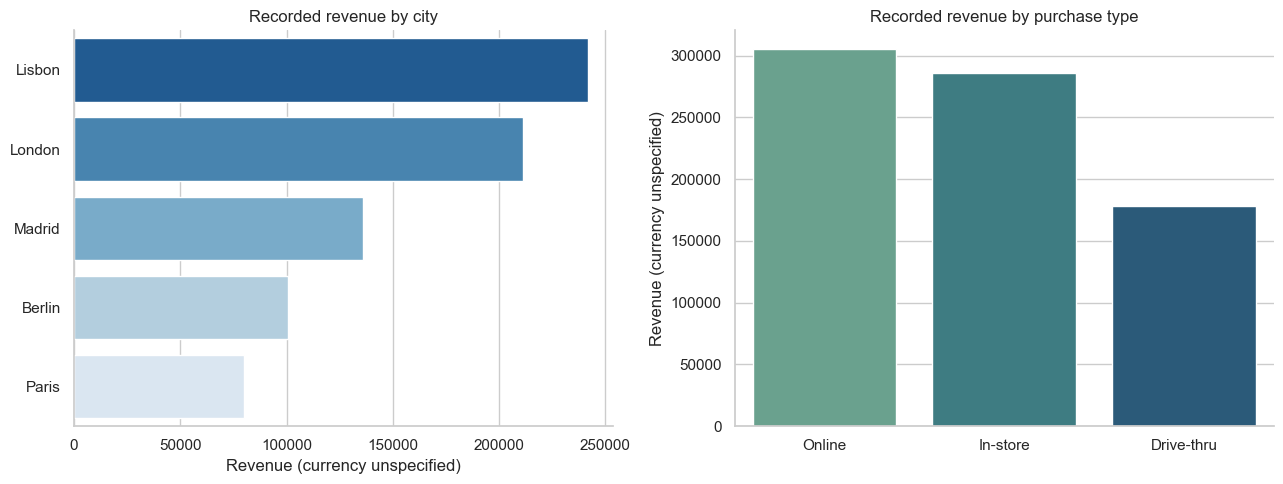

**Lisbon** leads cities with 31.4% of revenue. **Online** leads channels with 39.7%. These rankings describe recorded scale; differences may reflect product mix, coverage, or price realization.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
city_plot = data["cities"].sort_values("revenue", ascending=False)
sns.barplot(data=city_plot, x="revenue", y="city", hue="city", legend=False, palette="Blues_r", ax=axes[0])
axes[0].set(title="Recorded revenue by city", xlabel="Revenue (currency unspecified)", ylabel="")

channel_plot = data["channels"].sort_values("revenue", ascending=False)
sns.barplot(data=channel_plot, x="purchase_type", y="revenue", hue="purchase_type", legend=False, palette="crest", ax=axes[1])
axes[1].set(title="Recorded revenue by purchase type", xlabel="", ylabel="Revenue (currency unspecified)")
sns.despine()
plt.tight_layout()
plt.show()

city_leader = city_plot.iloc[0]
channel_leader = channel_plot.iloc[0]
display(Markdown(f"**{city_leader['city']}** leads cities with {percent(city_leader['revenue_share'])} of revenue. **{channel_leader['purchase_type']}** leads channels with {percent(channel_leader['revenue_share'])}. These rankings describe recorded scale; differences may reflect product mix, coverage, or price realization."))


### 5. Payment and weekday profile — operational context, not customer preference

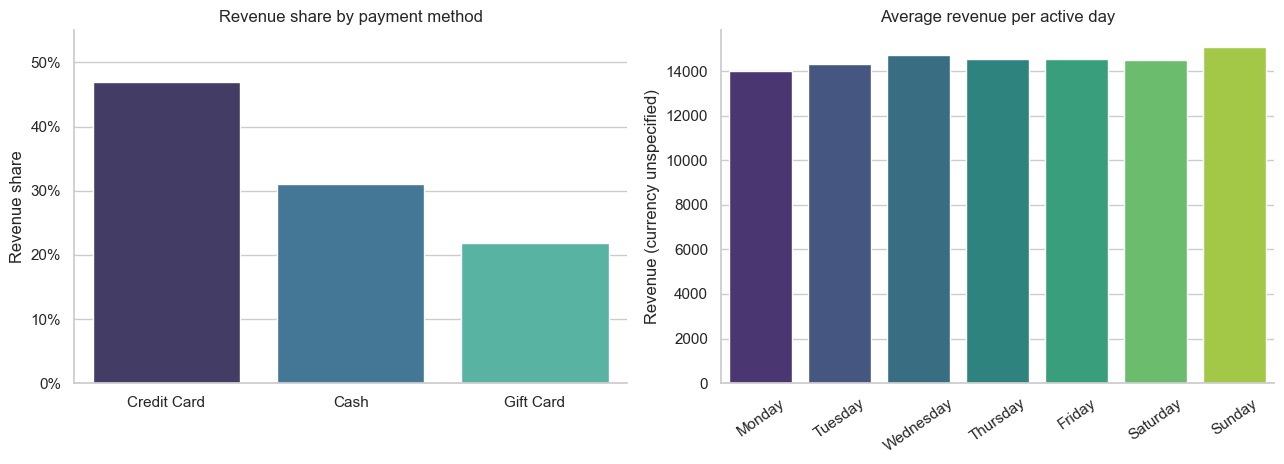

Payment shares describe recorded tender mix, not individual customer preference. Weekday comparisons use average revenue per active day so days with different observation counts remain more comparable.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
payment_plot = data["payments"].sort_values("revenue", ascending=False)
sns.barplot(data=payment_plot, x="payment_method", y="revenue_share", hue="payment_method", legend=False, palette="mako", ax=axes[0])
axes[0].set(title="Revenue share by payment method", xlabel="", ylabel="Revenue share", ylim=(0, .55))
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_plot = data["weekdays"].set_index("day_name").reindex(weekday_order).reset_index()
sns.barplot(data=weekday_plot, x="day_name", y="average_daily_revenue", hue="day_name", legend=False, palette="viridis", ax=axes[1])
axes[1].set(title="Average revenue per active day", xlabel="", ylabel="Revenue (currency unspecified)")
axes[1].tick_params(axis="x", rotation=35)
sns.despine()
plt.tight_layout()
plt.show()

display(Markdown("Payment shares describe recorded tender mix, not individual customer preference. Weekday comparisons use average revenue per active day so days with different observation counts remain more comparable."))


### 6. Opportunity matrix — prioritize what to validate next

dimension,segment,metric_evidence,business_hypothesis,recommended_validation_action,priority_score,evidence_strength
product,Burgers,revenue_share=49.0%; cumulative_share=49.0%,Concentration may simplify operational focus while increasing dependency on a limited menu set.,"Validate contribution margin, inventory resilience, substitution, and demand stability.",99.0,strong_descriptive
product,Fries,revenue_share=16.3%; cumulative_share=65.3%,Concentration may simplify operational focus while increasing dependency on a limited menu set.,"Validate contribution margin, inventory resilience, substitution, and demand stability.",66.3,strong_descriptive
purchase_type,Online,quantity=48999.16; weighted_price=6.23; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",55.3,moderate
city,London,quantity=33535.34; weighted_price=6.30; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",54.2,moderate
day_name,Monday,quantity=17665.06; weighted_price=6.34; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",53.6,moderate
day_name,Wednesday,quantity=18408.14; weighted_price=6.40; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",52.7,moderate
day_name,Thursday,quantity=17996.24; weighted_price=6.46; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",51.8,moderate
day_name,Tuesday,quantity=17586.49; weighted_price=6.52; baseline=6.58,The observed mix may contain a larger share of lower-priced products.,"Review product mix, price realization, discounting, and cost/capacity data before acting.",50.9,moderate


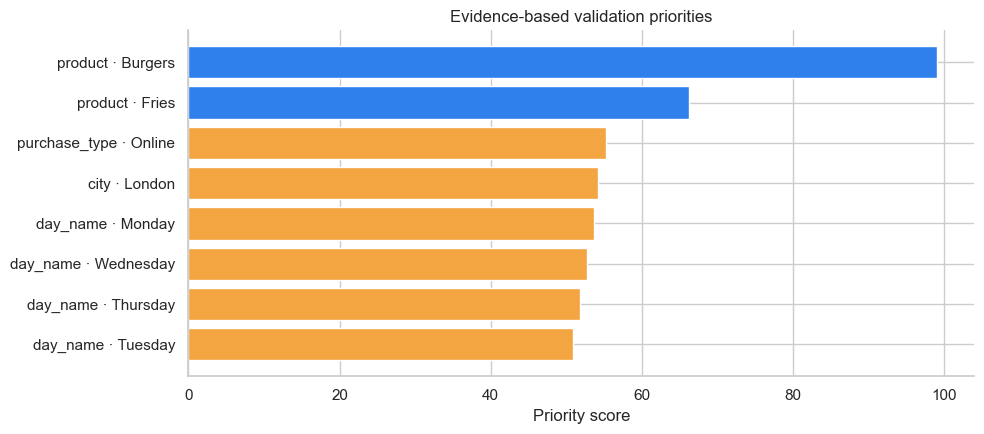

In [11]:
opportunities = data["opportunities"].sort_values("priority_score", ascending=False)
opportunity_view = opportunities[["dimension", "segment", "metric_evidence", "business_hypothesis", "recommended_validation_action", "priority_score", "evidence_strength"]]
display(compact_table(opportunity_view, rows=8).format({"priority_score": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(10, 4.5))
top_opportunities = opportunities.head(8).sort_values("priority_score")
labels = top_opportunities["dimension"] + " · " + top_opportunities["segment"]
colors = [PALETTE["blue"] if strength == "strong_descriptive" else PALETTE["amber"] for strength in top_opportunities["evidence_strength"]]
ax.barh(labels, top_opportunities["priority_score"], color=colors)
ax.set(title="Evidence-based validation priorities", xlabel="Priority score", ylabel="")
sns.despine()
plt.tight_layout()
plt.show()


## Takeaways

In [12]:
burger = data["products"].sort_values("revenue", ascending=False).iloc[0]
online = data["channels"].loc[data["channels"]["purchase_type"].eq("Online")].iloc[0]
london = data["cities"].loc[data["cities"]["city"].eq("London")].iloc[0]

display(Markdown(f''' 
### Findings supported by the data

1. **Revenue is highly product-concentrated.** {burger['product']} contributes {percent(burger['revenue_share'])}; the top three products contribute {percent(top_three_share)}.
2. **Main Course is the largest category.** It contributes {percent(categories.iloc[0]['revenue_share'])} of recorded revenue.
3. **Online has scale but lower weighted price.** It records {online['quantity']:,.2f} quantity at a weighted price of {online['average_selling_price']:,.2f}, below the portfolio baseline of {weighted_price:,.2f}.
4. **London shows a similar mix hypothesis.** Recorded quantity is {london['quantity']:,.2f} with weighted price {london['average_selling_price']:,.2f}, also below the portfolio baseline.

### Recommended actions

1. **Protect the core:** validate contribution margin, inventory resilience, substitution, and demand stability for Burgers before increasing dependency on it.
2. **Investigate mix, not discount blindly:** decompose Online and London by product mix, discounting, and price realization before changing prices or promotions.
3. **Instrument the missing grain:** capture transaction/order ID, customer ID, currency, unit definition, discounts, and cost data so AOV, repeat behavior, margin, and profitability become measurable.
4. **Run controlled tests:** use pilots or experiments for menu, promotion, or channel changes; this observational extract cannot establish causal lift.

### Decision posture

**Share with caveats.** Descriptive totals and shares reconcile and are suitable for portfolio storytelling. Profit, customer, order-level, period-growth, and causal decisions require additional data.
'''))


 
### Findings supported by the data

1. **Revenue is highly product-concentrated.** Burgers contributes 49.0%; the top three products contribute 80.2%.
2. **Main Course is the largest category.** It contributes 63.9% of recorded revenue.
3. **Online has scale but lower weighted price.** It records 48,999.16 quantity at a weighted price of 6.23, below the portfolio baseline of 6.58.
4. **London shows a similar mix hypothesis.** Recorded quantity is 33,535.34 with weighted price 6.30, also below the portfolio baseline.

### Recommended actions

1. **Protect the core:** validate contribution margin, inventory resilience, substitution, and demand stability for Burgers before increasing dependency on it.
2. **Investigate mix, not discount blindly:** decompose Online and London by product mix, discounting, and price realization before changing prices or promotions.
3. **Instrument the missing grain:** capture transaction/order ID, customer ID, currency, unit definition, discounts, and cost data so AOV, repeat behavior, margin, and profitability become measurable.
4. **Run controlled tests:** use pilots or experiments for menu, promotion, or channel changes; this observational extract cannot establish causal lift.

### Decision posture

**Share with caveats.** Descriptive totals and shares reconcile and are suitable for portfolio storytelling. Profit, customer, order-level, period-growth, and causal decisions require additional data.


### Reproducibility

- Source: `data/restaurant_sales_raw.csv`
- Production pipeline: `python run_pipeline.py`
- Project validation: `python validate_project.py`
- Notebook execution: `python -m jupyter nbconvert --execute --to notebook --inplace notebook/restaurant_sales_insight.ipynb`
- Dashboard: `streamlit run app.py`

All displayed metrics are derived from versioned artifacts in `output/`. Re-run the pipeline before this notebook whenever source data or analytical logic changes.